In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path

from eval_fluent_deeponet import (
    InterfaceIterationConfig,
    iterative_unknown_interface_inference,
    simulated_annealing_unknown_interface_inference,
    make_plot_dict_from_iterative_result,
    select_sample_indices_by_case_id,
    infer_edge_layout,
    PhysicsInterfaceConfig,
    physics_unknown_interface_inference,
)
from fluent_deeponet import DeepONet, FeatureNormalizer
from deeponet_fluent_dataset import build_fluent_deeponet_dataset

from plot import plot_prediction_imshow_from_points

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
device = torch.device("cuda:2")
ckpt_path = Path("results") / "060826_2" / "checkpoint.pt"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

model = DeepONet(**ckpt["model_config"]).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(device)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])


In [32]:
FIELD_MAP = {"pressure": "SV_P", "u": "SV_U", "v": "SV_V"}
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/")
DATASET_NAME = "channel_water"

def case_paths(ch):
    return {
        "design": ROOT_DIR / f"2d_geometry_specs/{DATASET_NAME}/{ch}.json",
        "mesh": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/{ch}.msh.h5",
        "dat": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/case2d.dat.h5",
    }

available_cases = [
    ch.name for ch in (ROOT_DIR / "runs_2d" / DATASET_NAME).iterdir()
    if all(case_paths(ch.name)[k].exists() for k in ("design", "mesh", "dat"))
]
case_files = {ch: case_paths(ch) for ch in available_cases}

bc_kwargs = {
    "inlet_v": 0.0,
    "outlet_p": 0.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

TEST_CH = ["channel_03"]
rng = np.random.default_rng(0)

test_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=TEST_CH,
    n_subdomains="adaptive",
    n_interface_points=256,
    n_boundary_points=256,
    interface_placement="fixed",
    interface_jitter=0,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

sample_test_ids = select_sample_indices_by_case_id(test_data, case_id=TEST_CH[0])

Setting n_realizations to 1 for fixed interface placement with no jitter
Processing case channel_03 realization=0 (n_subdomains=10)


# Simple Inference

In [ ]:
config = InterfaceIterationConfig(
    max_iter=10,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1,
    random_seed=0,
    init_mode="fixed_value",
    init_std_scale=1.0,
    init_value=[0, 0, 0],
    init_noise_std=0,
    reduce_mode="dct",
    query_batch_size=32768,
    sample_batch_size=20,
    preserve_wall_corners=False,
    verbose=True,
)

test_result = iterative_unknown_interface_inference(
    model=model,
    samples=[test_data["samples"][i] for i in sample_test_ids],
    branch_channel_names=test_data["branch_channel_names"],
    device=device,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=config,
)

print("Converged:", test_result["converged"], "iterations:", test_result["n_iter"])
print("Final prediction samples:", len(test_result["pred_samples"]))


In [ ]:
mse_history = test_result["interface_mse_history"]
plt.figure(figsize=(10, 5))
for k in range(mse_history.shape[1]):
    plt.plot(mse_history[:, k], alpha=0.7, linewidth=1.2, label=f"Channel {k+1}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Interface MSE")
plt.title(f"AR={TEST_AR} interface convergence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

channel_history = test_result["interface_mse_by_channel_history"]
plt.figure(figsize=(10, 5))
for k in range(channel_history.shape[1]):
    plt.plot(channel_history[:, k, 1], alpha=0.7, linewidth=1.2, label=f"Channel {k+1}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Interface MSE")
plt.title(f"AR={TEST_AR} temperature convergence at interfaces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
int_id = 1
val_id = 3
range_i = (0, 5)
br = test_data["samples"][sample_test_ids[int_id]]["branch"]
real_t = br[(br[:, 0] == 0) & (br[:, 3] == 1)][:, val_id + 4]
t_history = test_result["interface_left_values_history"][:, int_id, :, val_id]

plt.figure(figsize=(8, 6))
plt.plot(real_t, zorder=10, lw=2, label="Real value", c="r")
for i in range(range_i[0], range_i[1]):
    plt.plot(t_history[i, :], label=f"Iteration {i+1}")
    
plt.xlabel("point index (0 is bottom, 256 is top)", fontsize=16)
plt.ylabel("v velocity (m/s)", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
leg = plt.legend(loc=1, fontsize=13)
leg.set_zorder(20)
plt.show()


# SA inference

In [ ]:
# Simulated annealing interface solve: minimize predicted interface mismatch only.
# This does not add smoothness/range/truth penalties.

sa_config = InterfaceIterationConfig(
    max_iter=50000,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1.0,
    random_seed=0,
    init_mode="fixed",
    init_std_scale=1.0,
    init_value=[0, 0, 0],
    init_noise_std=0.0,
    reduce_mode="dct",
    query_batch_size=32768,
    sample_batch_size=20,
    preserve_wall_corners=False,
    verbose=True,
)

test_result_sa = simulated_annealing_unknown_interface_inference(
    model=model,
    samples=[test_data["samples"][i] for i in sample_test_ids],
    branch_channel_names=test_data["branch_channel_names"],
    device=device,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=sa_config,
    temperature0=None,          # None -> 0.1 * initial energy
    temperature_min=1.0e-8,
    proposal_sigma0=0.05,
    proposal_sigma_min=0.001,
    proposal_location="channel",
    sample_mode="fixed",
    objective="mean",
    verbose_every=100,
)

print("SA converged:", test_result_sa["converged"], "steps:", test_result_sa["n_iter"])
print("Best energy:", test_result_sa["best_energy"])
print("Best max MSE:", np.max(test_result_sa["best_interface_mse_history"][-1]))

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(test_result_sa["energy_history"])
plt.xlabel("Step", fontsize=16)
plt.ylabel("Energy", fontsize=16)
plt.title("Energy History", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.yscale("log")
plt.show()

In [216]:
pred = np.concat(test_result_sa["pred_samples"], axis=0)
truth = np.concat([test_data["samples"][i]["target"] for i in range(len(test_data["samples"]))], axis=0)
err = np.abs(pred - truth)

rel_l2 = np.linalg.norm(err, axis=0) / np.linalg.norm(truth, axis=0)
print(rel_l2)


[0.5888884  0.05530379 1.0952071 ]


In [ ]:
p_plot = make_plot_dict_from_iterative_result(
    result=test_result_sa,
    data=test_data,
    sample_indices=sample_test_ids,
)

output_channel_names = test_data["output_channel_names"]
for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=p_plot["x"],
        y=p_plot["y"],
        pred=p_plot["pred"],
        truth=p_plot["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_y_plot=200,
        metadata=test_data["metadata"],
        mesh_h5=case_files[TEST_CH[0]]["mesh"],
    )

In [ ]:
true_branch = np.stack([test_data["samples"][i]["branch"] for i in sample_test_ids], axis=0).astype(np.float32)
infer_branch = np.asarray(test_result_sa["branch_final"], dtype=np.float32)

layout = infer_edge_layout(true_branch[0], test_data["branch_channel_names"])
channel_labels = ["pressure", "u-velocity", "v-velocity"]

n_sub = true_branch.shape[0]
value_idx = layout.value_channels

true_interfaces = []
infer_interfaces = []
for interface_id in range(1, n_sub):
    i_right = infer_branch[interface_id - 1][np.ix_(layout.right, value_idx)]
    i_left = infer_branch[interface_id][np.ix_(layout.left, value_idx)]

    true_interfaces.append(true_branch[interface_id][np.ix_(layout.left, value_idx)])
    infer_interfaces.append(0.5 * (i_right + i_left))

true_interfaces = np.stack(true_interfaces, axis=0)   # (n_if, n_y, n_ch)
infer_interfaces = np.stack(infer_interfaces, axis=0) # (n_if, n_y, n_ch)

err = infer_interfaces - true_interfaces

yn_mean = y_normalizer.mean.detach().cpu().numpy().astype(np.float32).reshape(1, 1, -1)
yn_std = y_normalizer.std.detach().cpu().numpy().astype(np.float32).reshape(1, 1, -1)
yn_std = np.maximum(yn_std, 1.0e-12)

true_interfaces_norm = (true_interfaces - yn_mean) / yn_std
infer_interfaces_norm = (infer_interfaces - yn_mean) / yn_std
err_norm = infer_interfaces_norm - true_interfaces_norm
abs_err_norm = np.abs(err_norm)

# Figure 1: MAE by interface (line per channel)
mae_if_ch = abs_err_norm.mean(axis=1)  # (n_if, n_ch)
plt.figure(figsize=(9, 4))
for ch in range(mae_if_ch.shape[1]):
    plt.plot(np.arange(1, mae_if_ch.shape[0] + 1), mae_if_ch[:, ch], marker='o', label=channel_labels[ch])
plt.xlabel("Interior interface index")
plt.ylabel("MAE (normalized)")
plt.title(f"SA interface-condition error vs truth ({TEST_CH[0]}): by interface, normalized")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Error along y at given interface
int_eval = 0
fig, axes = plt.subplots(3, 1, figsize=(8, 2.2 * 4), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(true_interfaces[int_eval, :, ch], lw=2, label="Truth")
    ax.plot(infer_interfaces[int_eval, :, ch], lw=2, label="Inferred")
    ax.set_ylabel(f"{channel_labels[ch]}\nMAE (norm)")
    ax.legend(loc=1)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("point index (0 is bottom, 256 is top)")
fig.suptitle(f"SA interface-condition error vs truth ({TEST_CH[0]}) at interface {int_eval}", y=1.02)
fig.tight_layout()
plt.show()

global_mae_ch = abs_err_norm.mean(axis=(0, 1))
print("Global MAE per channel normalized:")
for label, val in zip(channel_labels, global_mae_ch):
    print(f"  {label:>22s}: {val:.6e}")
print("Overall MAE (all interfaces, points, channels):", float(abs_err_norm.mean()))

In [ ]:
best_z = test_result_sa["best_z"]
assert isinstance(best_z, np.ndarray)
channels = ["pressure", "u-velocity", "v-velocity"]
for c in range(best_z.shape[2]):
    plt.figure(figsize=(10, 6))
    for i in range(best_z.shape[0]):
        plt.plot(best_z[i, :, c], label=f"interface {i}")
    plt.xlabel("DCT coefficient index (higher is higher frequency)", fontsize=14)
    plt.ylabel("DCT coefficient value", fontsize=14)
    plt.legend(fontsize=12)
    plt.title(f"DCT coefficients of {channels[c]}", fontsize=16)
    plt.show()

# Physics inference

In [ ]:
samples = [test_data["samples"][i] for i in sample_test_ids]
metadata = [test_data["metadata"][i] for i in sample_test_ids]

phys_config = PhysicsInterfaceConfig(
    max_iter=50,
    lr=1e-2,
    optimizer="lbfgs",        # try "lbfgs" after Adam converges roughly
    tol=1e-6,
    random_seed=0,
    init_mode="fixed",       # aliases to fixed_with_noise
    init_value=[0.0, 0.0, 0.0],  # [pressure, u, v] for your 3-output model
    init_noise_std=0.0,
    optimize_fields=["pressure", "u", "v"],
    viscosity=1.003E-3,
    length_unit_scale=1e-3,  # metadata unit is mm; converts to m
    alpha_traction=1.0,
    alpha_flux=1.0,
    alpha_dirichlet=1.0,
    alpha_smooth=1e-4,
    alpha_value_l2=0,
    optimize_pressure_offsets=False,
    query_batch_size=32768,
    verbose=True,
    verbose_every=25,
)

result_phys = physics_unknown_interface_inference(
    model=model,
    samples=samples,
    branch_channel_names=test_data["branch_channel_names"],
    output_channel_names=test_data["output_channel_names"],
    device=device,
    y_normalizer=y_normalizer,
    metadata=metadata,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=phys_config,
)

print("Converged:", result_phys["converged"], "iterations:", result_phys["n_iter"])
print("Final physics losses:", result_phys["physics_loss_history"][-1])

plot_dict = make_plot_dict_from_iterative_result(
    result_phys,
    test_data,
    sample_test_ids,
    output_channel_names=test_data["output_channel_names"],
)


iter=0001 | loss=3.523125e+00 | traction=3.285653e-01 | flux=7.614439e-03 | boundary=3.186945e+00 | smooth=8.933086e-04
iter=0025 | loss=4.132217e-03 | traction=3.023064e-03 | flux=1.563097e-04 | boundary=9.528428e-04 | smooth=2.116121e-06
iter=0050 | loss=4.132217e-03 | traction=3.023064e-03 | flux=1.563097e-04 | boundary=9.528428e-04 | smooth=2.116121e-06
Converged: False iterations: 50
Final physics losses: {'loss': 0.0041322167962789536, 'traction': 0.003023064462468028, 'flux': 0.00015630967391189188, 'dirichlet': 0.0009528427617624402, 'smooth': 2.1161208678677212e-06, 'value_l2': 0.688675582408905, 'max_abs_traction_res': 104.0408935546875, 'max_abs_flux_res': 7.204143912531435e-07, 'iteration': 50.0, 'traction_scale': 415.0386657714844, 'flux_scale': 4.349945016124987e-05}


In [ ]:
pred = np.concat(result_phys["pred_samples"], axis=0)
truth = np.concat([test_data["samples"][i]["target"] for i in range(len(test_data["samples"]))], axis=0)
err = np.abs(pred - truth)

rel_l2 = np.linalg.norm(err, axis=0) / np.linalg.norm(truth, axis=0)
print(rel_l2)


[0.02550801 0.00996342 0.2168467 ]


In [ ]:
np.abs(plot_dict["pred"] - plot_dict["truth"]).max(axis=0)

array([1.4913745e+02, 1.1887789e-01, 4.5569122e-02], dtype=float32)

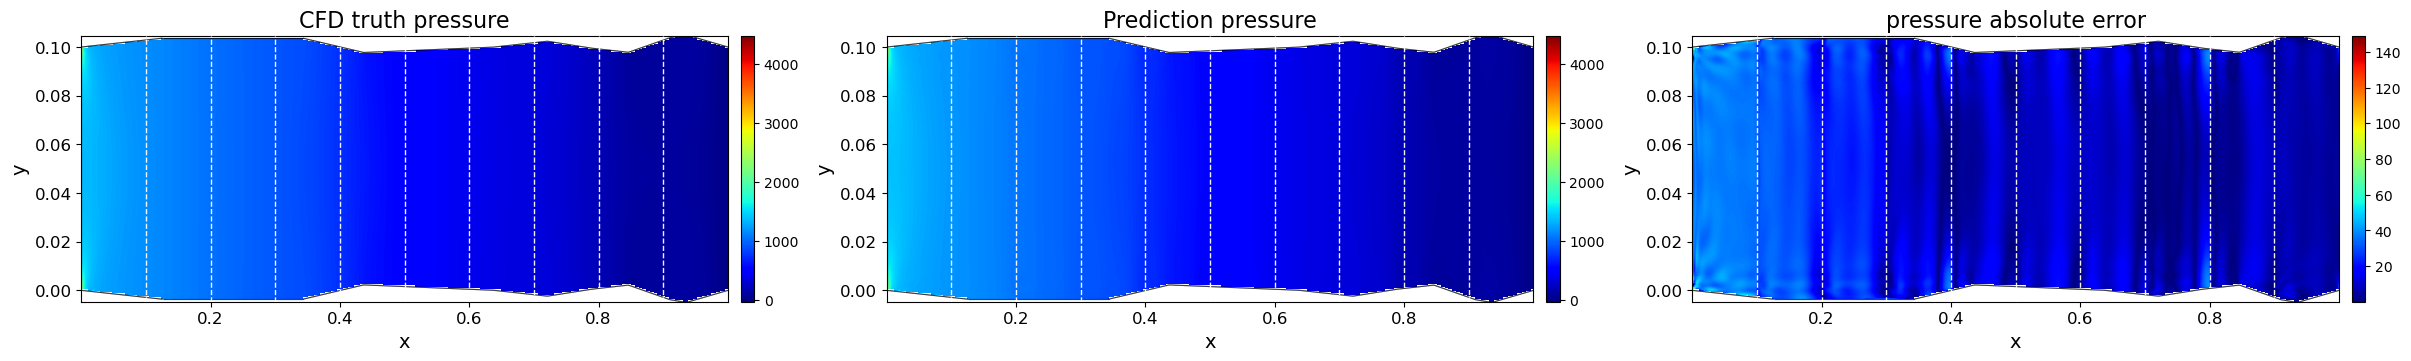

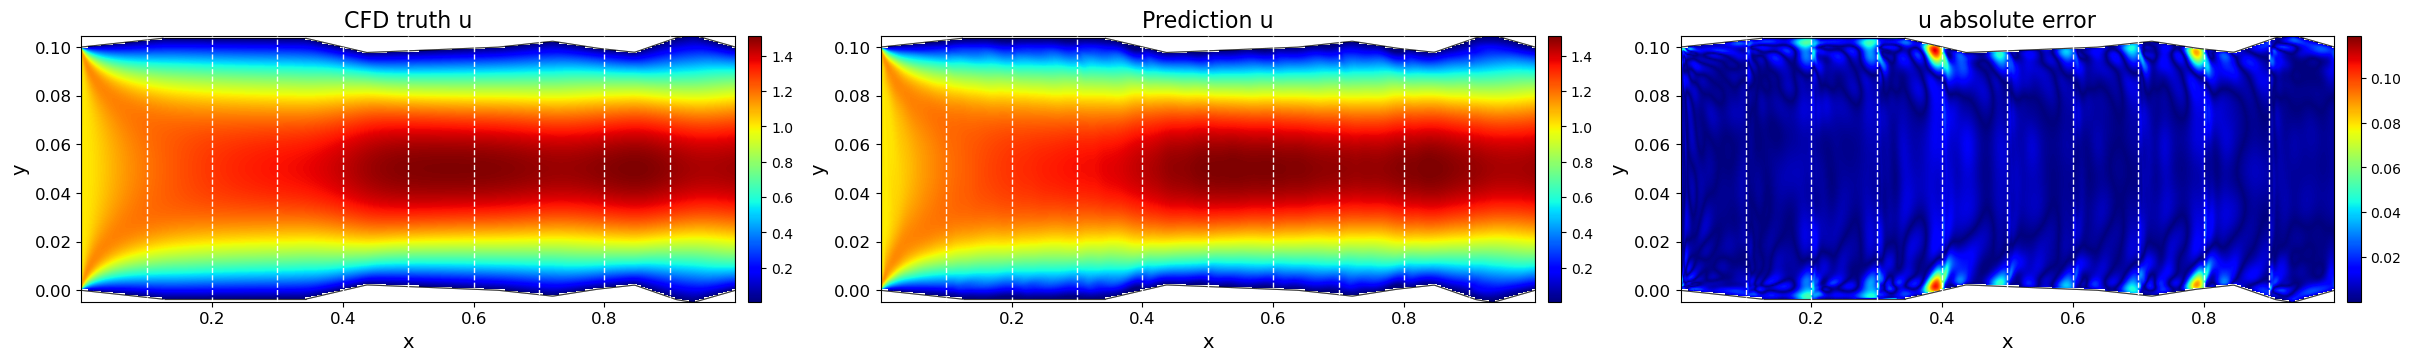

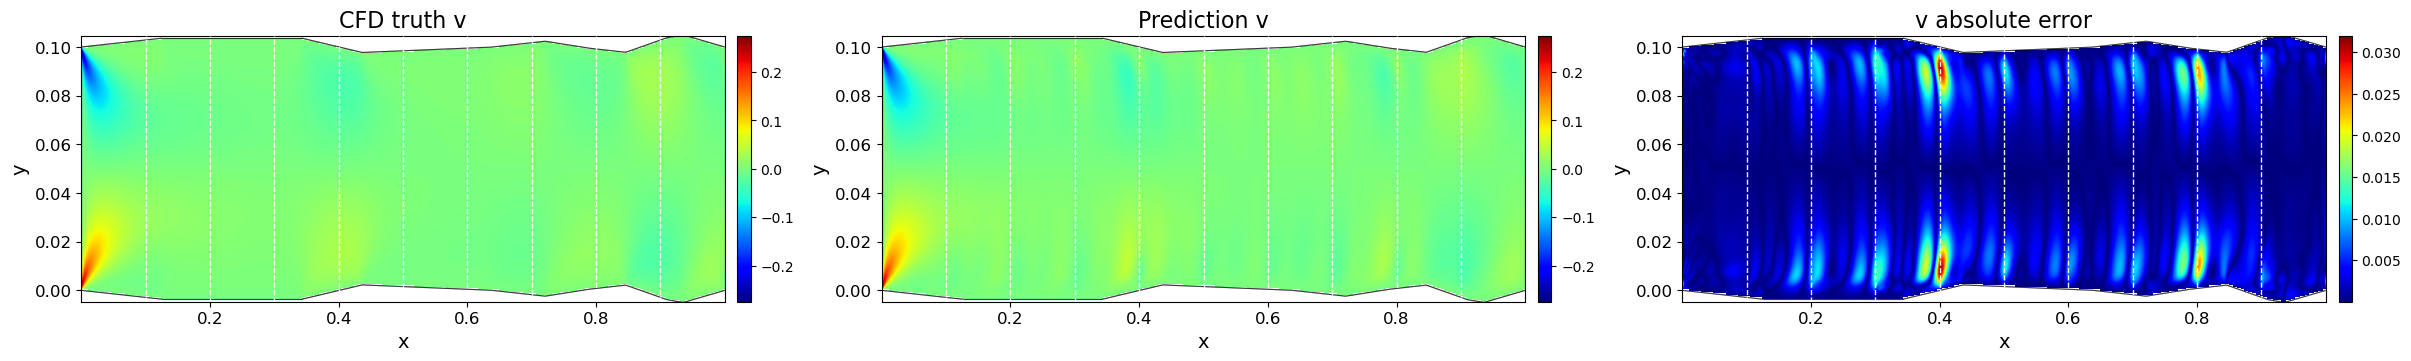

In [ ]:
output_channel_names = test_data["output_channel_names"]
for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=plot_dict["x"],
        y=plot_dict["y"],
        pred=plot_dict["pred"],
        truth=plot_dict["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_y_plot=200,
        metadata=test_data["metadata"],
        mesh_h5=case_files[TEST_CH[0]]["mesh"],
    )

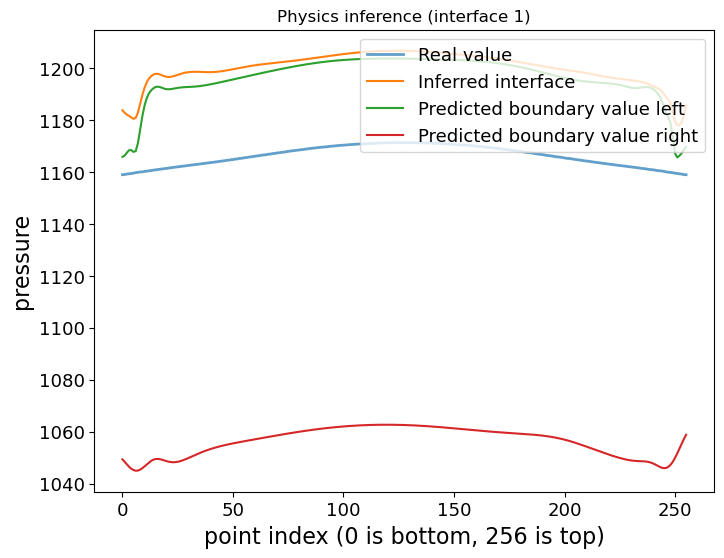

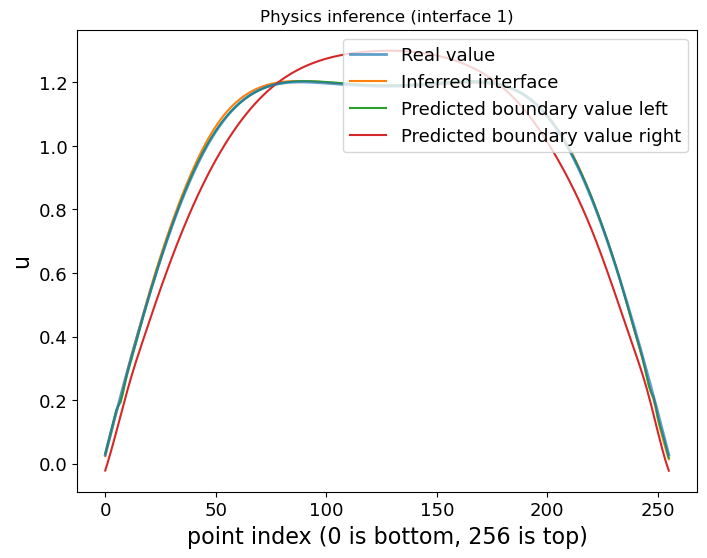

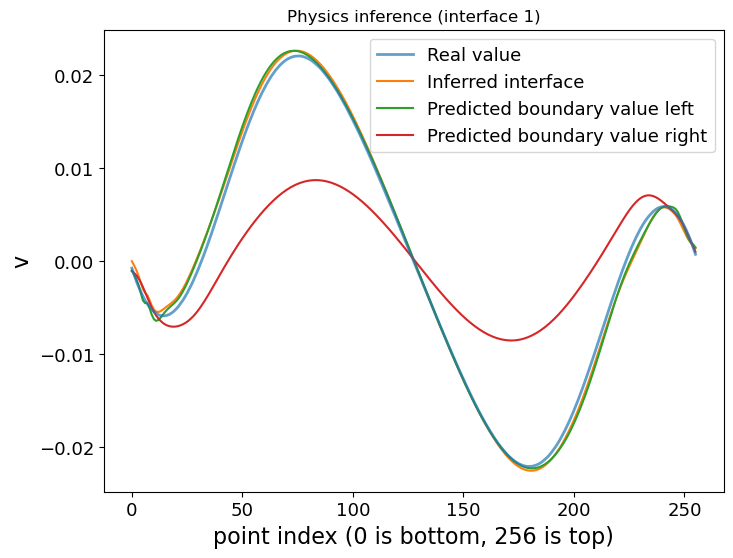

In [ ]:
output_channel_names = test_data["output_channel_names"]
int_id = 1
for val_id in range(3):
    br = test_data["samples"][sample_test_ids[int_id]]["branch"]
    real_t = br[(br[:, 0] == 0) & (br[:, 3] == 1)][:, val_id + 4]
    br_pred = result_phys["branch_final"][int_id]
    pred_t = br_pred[(br_pred[:, 0] == 0) & (br_pred[:, 3] == 1)][:, val_id + 4]
    pred_left = y_normalizer.decode(result_phys["pred_left_interface"]).cpu().numpy()
    pred_right = y_normalizer.decode(result_phys["pred_right_interface"]).cpu().numpy()
    pred_left = pred_left[int_id, :, val_id]
    pred_right = pred_right[int_id, :, val_id]


    plt.figure(figsize=(8, 6))
    plt.plot(real_t, zorder=10, lw=2, label="Real value", alpha=0.7)
    plt.plot(pred_t, label="Inferred interface")
    plt.plot(pred_left, label="Predicted boundary value left")
    plt.plot(pred_right, label="Predicted boundary value right")
        
    plt.xlabel("point index (0 is bottom, 256 is top)", fontsize=16)
    plt.ylabel(f"{output_channel_names[val_id]}", fontsize=16)
    plt.title(f"Physics inference (interface {int_id})")
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    leg = plt.legend(loc=1, fontsize=13)
    leg.set_zorder(20)
    plt.show()


# Physics inference weight sweep

Sweep traction / flux / Dirichlet loss weights, save metrics, field predictions, interface conditions, and plots for each combination.

In [40]:
import itertools
import json
from dataclasses import replace

sweep_samples = [test_data["samples"][i] for i in sample_test_ids]
sweep_metadata = [test_data["metadata"][i] for i in sample_test_ids]
sweep_output_channel_names = list(test_data["output_channel_names"])
sweep_channel_labels = ["pressure", "u-velocity", "v-velocity"]

SWEEP_BASE_PHYS_CONFIG = PhysicsInterfaceConfig(
    max_iter=50,
    lr=1e-2,
    optimizer="lbfgs",
    tol=1e-6,
    random_seed=0,
    init_mode="fixed",
    init_value=[0.0, 0.0, 0.0],
    init_noise_std=0.0,
    optimize_fields=["pressure", "u", "v"],
    viscosity=1.003E-3,
    length_unit_scale=1e-3,
    alpha_traction=1.0,
    alpha_flux=1.0,
    alpha_dirichlet=1.0,
    alpha_smooth=1e-4,
    alpha_value_l2=0,
    optimize_pressure_offsets=False,
    query_batch_size=32768,
    verbose=False,
    verbose_every=25,
)

SWEEP_ALPHA_VALUES = [0.1, 0.3, 1.0, 3, 10.0]
SWEEP_WEIGHT_COMBINATIONS = list(
    itertools.product(SWEEP_ALPHA_VALUES, SWEEP_ALPHA_VALUES, SWEEP_ALPHA_VALUES)
)

SWEEP_OUTPUT_ROOT = Path("results") / "physics_weight_sweep" / TEST_CH[0]
SWEEP_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Ground-truth interior interface values (shared across all weight runs).
sweep_true_branch = np.stack(
    [test_data["samples"][i]["branch"] for i in sample_test_ids], axis=0
).astype(np.float32)
sweep_layout = infer_edge_layout(sweep_true_branch[0], test_data["branch_channel_names"])
sweep_value_idx = sweep_layout.value_channels
sweep_n_sub = sweep_true_branch.shape[0]

sweep_true_interfaces = []
for interface_id in range(1, sweep_n_sub):
    sweep_true_interfaces.append(
        sweep_true_branch[interface_id][np.ix_(sweep_layout.left, sweep_value_idx)]
    )
sweep_true_interfaces = np.stack(sweep_true_interfaces, axis=0)

print(f"Running {len(SWEEP_WEIGHT_COMBINATIONS)} weight combinations -> {SWEEP_OUTPUT_ROOT}")

Running 125 weight combinations -> results/physics_weight_sweep/channel_03


In [44]:
def _sweep_infer_interfaces_from_branch(infer_branch: np.ndarray) -> np.ndarray:
    interfaces = []
    for interface_id in range(1, sweep_n_sub):
        i_right = infer_branch[interface_id - 1][np.ix_(sweep_layout.right, sweep_value_idx)]
        i_left = infer_branch[interface_id][np.ix_(sweep_layout.left, sweep_value_idx)]
        interfaces.append(0.5 * (i_right + i_left))
    return np.stack(interfaces, axis=0)


def _sweep_weight_run_name(alpha_traction: float, alpha_flux: float, alpha_dirichlet: float) -> str:
    return (
        f"traction_{alpha_traction:g}_flux_{alpha_flux:g}_"
        f"dirichlet_{alpha_dirichlet:g}"
    )


def _sweep_save_interface_profile_plots(result_phys, run_dir: Path, int_id: int = 1) -> None:
    iface_plot_dir = run_dir / "plots" / "interfaces"
    iface_plot_dir.mkdir(parents=True, exist_ok=True)

    br = test_data["samples"][sample_test_ids[int_id]]["branch"]
    br_pred = result_phys["branch_final"][int_id]
    pred_left = y_normalizer.decode(result_phys["pred_left_interface"]).cpu().numpy()
    pred_right = y_normalizer.decode(result_phys["pred_right_interface"]).cpu().numpy()

    for val_id, field_name in enumerate(sweep_output_channel_names):
        real_t = br[(br[:, 0] == 0) & (br[:, 3] == 1)][:, val_id + 4]
        pred_t = br_pred[(br_pred[:, 0] == 0) & (br_pred[:, 3] == 1)][:, val_id + 4]
        pred_left_line = pred_left[int_id, :, val_id]
        pred_right_line = pred_right[int_id, :, val_id]

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(real_t, zorder=10, lw=2, label="Real value", alpha=0.7)
        ax.plot(pred_t, label="Inferred interface")
        ax.plot(pred_left_line, label="Predicted boundary value left")
        ax.plot(pred_right_line, label="Predicted boundary value right")
        ax.set_xlabel("point index (0 is bottom, 256 is top)", fontsize=16)
        ax.set_ylabel(field_name, fontsize=16)
        ax.set_title(f"Physics inference (interface {int_id})")
        ax.legend(loc=1, fontsize=13)
        fig.tight_layout()
        fig.savefig(
            iface_plot_dir / f"interface{int_id}_{field_name}.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.close(fig)


def _sweep_save_interface_error_plots(
    infer_interfaces: np.ndarray,
    run_dir: Path,
    run_name: str,
    int_eval: int = 0,
) -> None:
    yn_mean = y_normalizer.mean.detach().cpu().numpy().astype(np.float32).reshape(1, 1, -1)
    yn_std = y_normalizer.std.detach().cpu().numpy().astype(np.float32).reshape(1, 1, -1)
    yn_std = np.maximum(yn_std, 1.0e-12)

    true_norm = (sweep_true_interfaces - yn_mean) / yn_std
    infer_norm = (infer_interfaces - yn_mean) / yn_std
    abs_err_norm = np.abs(infer_norm - true_norm)

    iface_plot_dir = run_dir / "plots" / "interfaces"
    iface_plot_dir.mkdir(parents=True, exist_ok=True)

    mae_if_ch = abs_err_norm.mean(axis=1)
    fig, ax = plt.subplots(figsize=(9, 4))
    for ch in range(mae_if_ch.shape[1]):
        ax.plot(
            np.arange(1, mae_if_ch.shape[0] + 1),
            mae_if_ch[:, ch],
            marker="o",
            label=sweep_channel_labels[ch],
        )
    ax.set_xlabel("Interior interface index")
    ax.set_ylabel("MAE (normalized)")
    ax.set_title(f"{run_name}: interface error by interface")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(iface_plot_dir / "interface_mae_by_index.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    fig, axes = plt.subplots(3, 1, figsize=(8, 2.2 * 4), sharex=True)
    for ch, ax in enumerate(axes):
        ax.plot(sweep_true_interfaces[int_eval, :, ch], lw=2, label="Truth")
        ax.plot(infer_interfaces[int_eval, :, ch], lw=2, label="Inferred")
        ax.set_ylabel(sweep_channel_labels[ch])
        ax.legend(loc=1)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("point index (0 is bottom, 256 is top)")
    fig.suptitle(f"{run_name}: interface {int_eval} profiles", y=1.02)
    fig.tight_layout()
    fig.savefig(
        iface_plot_dir / f"interface{int_eval}_profiles.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.close(fig)


sweep_summary_rows = []

for run_idx, (alpha_traction, alpha_flux, alpha_dirichlet) in enumerate(SWEEP_WEIGHT_COMBINATIONS):
    run_name = _sweep_weight_run_name(alpha_traction, alpha_flux, alpha_dirichlet)
    run_dir = SWEEP_OUTPUT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    sweep_phys_config = replace(
        SWEEP_BASE_PHYS_CONFIG,
        alpha_traction=alpha_traction,
        alpha_flux=alpha_flux,
        alpha_dirichlet=alpha_dirichlet,
        verbose=(run_idx == 0),
    )

    print(
        f"[{run_idx + 1}/{len(SWEEP_WEIGHT_COMBINATIONS)}] "
        f"traction={alpha_traction:g}, flux={alpha_flux:g}, dirichlet={alpha_dirichlet:g}"
    )

    sweep_result = physics_unknown_interface_inference(
        model=model,
        samples=sweep_samples,
        branch_channel_names=test_data["branch_channel_names"],
        output_channel_names=sweep_output_channel_names,
        device=device,
        y_normalizer=y_normalizer,
        metadata=sweep_metadata,
        local_aspect_mean=local_aspect_mean,
        local_aspect_std=local_aspect_std,
        config=sweep_phys_config,
    )

    sweep_plot_dict = make_plot_dict_from_iterative_result(
        sweep_result,
        test_data,
        sample_test_ids,
        output_channel_names=sweep_output_channel_names,
    )

    pred = sweep_plot_dict["pred"]
    truth = sweep_plot_dict["truth"]
    err = np.abs(pred - truth)
    rel_l2 = np.linalg.norm(err, axis=0) / np.maximum(np.linalg.norm(truth, axis=0), 1.0e-12)
    overall_avg_rel_l2 = float(np.mean(rel_l2))
    max_field_err = err.max(axis=0)

    infer_branch = np.asarray(sweep_result["branch_final"], dtype=np.float32)
    infer_interfaces = _sweep_infer_interfaces_from_branch(infer_branch)
    pred_left = y_normalizer.decode(sweep_result["pred_left_interface"]).cpu().numpy()
    pred_right = y_normalizer.decode(sweep_result["pred_right_interface"]).cpu().numpy()

    final_losses = sweep_result["physics_loss_history"][-1]
    if hasattr(final_losses, "items"):
        final_losses = {k: float(v) for k, v in final_losses.items()}

    metrics = {
        "run_name": run_name,
        "alpha_traction": float(alpha_traction),
        "alpha_flux": float(alpha_flux),
        "alpha_dirichlet": float(alpha_dirichlet),
        "converged": bool(sweep_result["converged"]),
        "n_iter": int(sweep_result["n_iter"]),
        "rel_l2": {
            name: float(rel_l2[i]) for i, name in enumerate(sweep_output_channel_names)
        },
        "overall_avg_rel_l2": overall_avg_rel_l2,
        "max_field_error": {
            name: float(max_field_err[i]) for i, name in enumerate(sweep_output_channel_names)
        },
        "final_physics_losses": final_losses,
    }

    with open(run_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    np.savez_compressed(
        run_dir / "field_predictions.npz",
        pred=pred.astype(np.float32),
        truth=truth.astype(np.float32),
        x=sweep_plot_dict["x"].astype(np.float32),
        y=sweep_plot_dict["y"].astype(np.float32),
        rel_l2=rel_l2.astype(np.float32),
        overall_avg_rel_l2=np.asarray(overall_avg_rel_l2, dtype=np.float32),
        max_field_error=max_field_err.astype(np.float32),
        output_channel_names=np.asarray(sweep_output_channel_names),
    )

    np.savez_compressed(
        run_dir / "interface_conditions.npz",
        true_interfaces=sweep_true_interfaces.astype(np.float32),
        infer_interfaces=infer_interfaces.astype(np.float32),
        branch_final=infer_branch,
        pred_left_interface=pred_left.astype(np.float32),
        pred_right_interface=pred_right.astype(np.float32),
    )

    plot_dir = run_dir / "plots" / "fields"
    for field_name in sweep_output_channel_names:
        field_idx = sweep_output_channel_names.index(field_name)
        plot_prediction_imshow_from_points(
            x=sweep_plot_dict["x"],
            y=sweep_plot_dict["y"],
            pred=sweep_plot_dict["pred"],
            truth=sweep_plot_dict["truth"],
            field_name=field_name,
            field_idx=field_idx,
            n_y_plot=200,
            metadata=test_data["metadata"],
            mesh_h5=case_files[TEST_CH[0]]["mesh"],
            output_dir=str(plot_dir),
            filename_prefix="field",
            show=False,
        )

    _sweep_save_interface_profile_plots(sweep_result, run_dir, int_id=1)
    _sweep_save_interface_error_plots(infer_interfaces, run_dir, run_name, int_eval=0)

    sweep_summary_rows.append(metrics)
    
    print(f"  overall_avg_rel_l2: {overall_avg_rel_l2:.4e}")
    print(
        "  rel_l2:",
        {name: f"{metrics['rel_l2'][name]:.4e}" for name in sweep_output_channel_names},
    )
    print(
        "  max field err:",
        {name: f"{metrics['max_field_error'][name]:.4e}" for name in sweep_output_channel_names},
    )

with open(SWEEP_OUTPUT_ROOT / "summary.json", "w", encoding="utf-8") as f:
    json.dump(sweep_summary_rows, f, indent=2)

print(f"Saved sweep results to {SWEEP_OUTPUT_ROOT}")

[1/125] traction=0.1, flux=0.1, dirichlet=0.1
iter=0001 | loss=2.286268e-01 | traction=2.325505e-01 | flux=2.825227e-03 | boundary=2.050891e+00 | smooth=1.862934e-03
iter=0019 | loss=4.132660e-04 | traction=3.028935e-03 | flux=1.564593e-04 | boundary=9.472639e-04 | smooth=2.067567e-06
iter=0019 | stopping: loss unchanged for 10 iterations
Saved: results/physics_weight_sweep/channel_03/traction_0.1_flux_0.1_dirichlet_0.1/plots/fields/field_pressure.png
Saved: results/physics_weight_sweep/channel_03/traction_0.1_flux_0.1_dirichlet_0.1/plots/fields/field_u.png
Saved: results/physics_weight_sweep/channel_03/traction_0.1_flux_0.1_dirichlet_0.1/plots/fields/field_v.png
  overall_avg_rel_l2: 8.2783e-02
  rel_l2: {'pressure': '2.6175e-02', 'u': '9.6837e-03', 'v': '2.1249e-01'}
  max field err: {'pressure': '1.4978e+02', 'u': '1.1889e-01', 'v': '4.5595e-02'}
[2/125] traction=0.1, flux=0.1, dirichlet=0.3
Saved: results/physics_weight_sweep/channel_03/traction_0.1_flux_0.1_dirichlet_0.3/plots/fie

In [45]:
# Quick summary table across all weight combinations.
print(f"{'run_name':<45} {'avg rel_l2':<12} {'rel_l2 (p,u,v)':<40} {'max err (p,u,v)':<40}")
print("-" * 137)
for row in sweep_summary_rows:
    rel = row["rel_l2"]
    mx = row["max_field_error"]
    rel_str = ", ".join(f"{rel[n]:.3e}" for n in sweep_output_channel_names)
    mx_str = ", ".join(f"{mx[n]:.3e}" for n in sweep_output_channel_names)
    avg_rel_l2 = row.get("overall_avg_rel_l2", float(np.mean(list(rel.values()))))
    print(f"{row['run_name']:<45} {avg_rel_l2:<12.3e} {rel_str:<40} {mx_str:<40}")

run_name                                      avg rel_l2   rel_l2 (p,u,v)                           max err (p,u,v)                         
-----------------------------------------------------------------------------------------------------------------------------------------
traction_0.1_flux_0.1_dirichlet_0.1           8.278e-02    2.618e-02, 9.684e-03, 2.125e-01          1.498e+02, 1.189e-01, 4.559e-02         
traction_0.1_flux_0.1_dirichlet_0.3           4.941e-02    1.963e-02, 6.047e-03, 1.226e-01          1.549e+02, 1.189e-01, 4.547e-02         
traction_0.1_flux_0.1_dirichlet_1             2.870e-02    1.016e-02, 4.293e-03, 7.166e-02          1.670e+02, 1.188e-01, 4.547e-02         
traction_0.1_flux_0.1_dirichlet_3             1.844e-02    3.631e-03, 3.607e-03, 4.810e-02          1.747e+02, 1.188e-01, 4.546e-02         
traction_0.1_flux_0.1_dirichlet_10            1.727e-02    3.003e-03, 3.486e-03, 4.533e-02          1.783e+02, 1.187e-01, 4.549e-02         
traction_0.1_flu

In [ ]:
d = Path("results/physics_weight_sweep/channel_03")
min_overall = (float("inf"), float("inf"), float("inf"), None)
min_pressure = (float("inf"), "")
min_u = (float("inf"), "")
min_v = (float("inf"), "")
summary = json.load(open(d / "summary.json", "r"))
for run in summary:
    l2 = run["rel_l2"]
    if l2["pressure"] < min_pressure[0]:
        min_pressure = (l2["pressure"], run["run_name"])
    if l2["u"] < min_u[0]:
        min_u = (l2["u"], run["run_name"])
    if l2["v"] < min_v[0]:
        min_v = (l2["v"], run["run_name"])
    if sum(l2.values()) < sum(min_overall[:3]):
        min_overall = (l2["pressure"], l2["u"], l2["v"], run["run_name"])
print(min_overall)
print(min_pressure)
print(min_u)
print(min_v)

(0.0030984131153672934, 0.0034752970095723867, 0.044128116220235825, 'traction_0.1_flux_0.3_dirichlet_10')
(0.003002756042405963, 'traction_0.1_flux_0.1_dirichlet_10')
(0.003471819683909416, 'traction_0.1_flux_3_dirichlet_10')
(0.04165021702647209, 'traction_0.1_flux_10_dirichlet_10')


Inspecting: traction_0.1_flux_0.3_dirichlet_10
overall_avg_rel_l2: 0.01690060831606388
rel_l2: {'pressure': 0.0030984131153672934, 'u': 0.0034752970095723867, 'v': 0.044128116220235825}
max_field_error: {'pressure': 178.408203125, 'u': 0.11868917942047119, 'v': 0.0454704612493515}
final_physics_losses: {'loss': 0.0018620890332385898, 'traction': 0.005846461281180382, 'flux': 0.00016070013225544244, 'dirichlet': 0.00012292327301111072, 'smooth': 1.1910734656339628e-06, 'value_l2': 0.6676387786865234, 'max_abs_traction_res': 127.4981689453125, 'max_abs_flux_res': 7.369380909949541e-07, 'iteration': 30.0, 'traction_scale': 415.0386657714844, 'flux_scale': 4.349945016124987e-05}


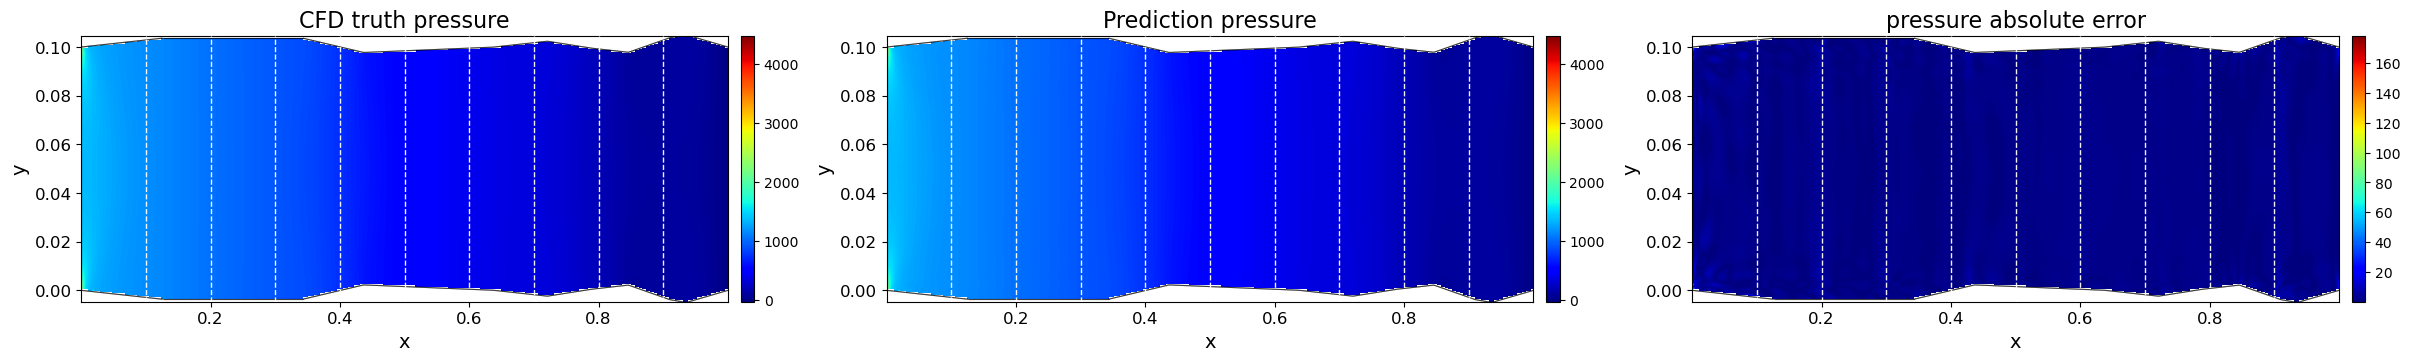

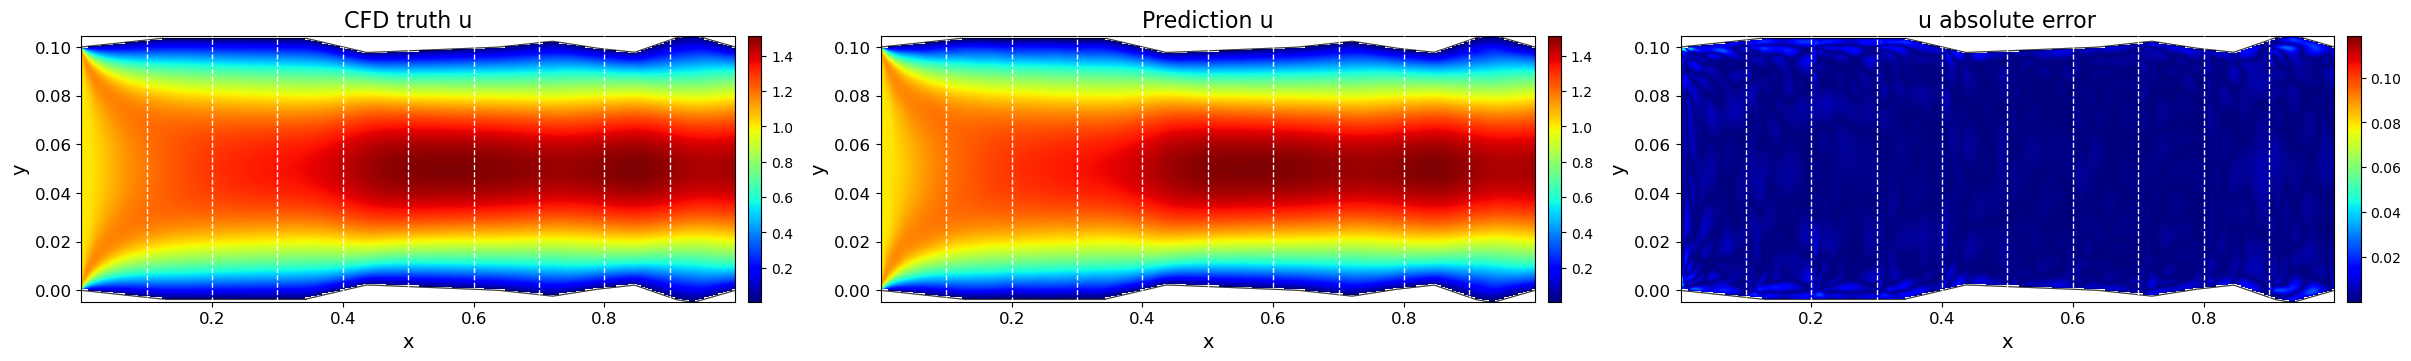

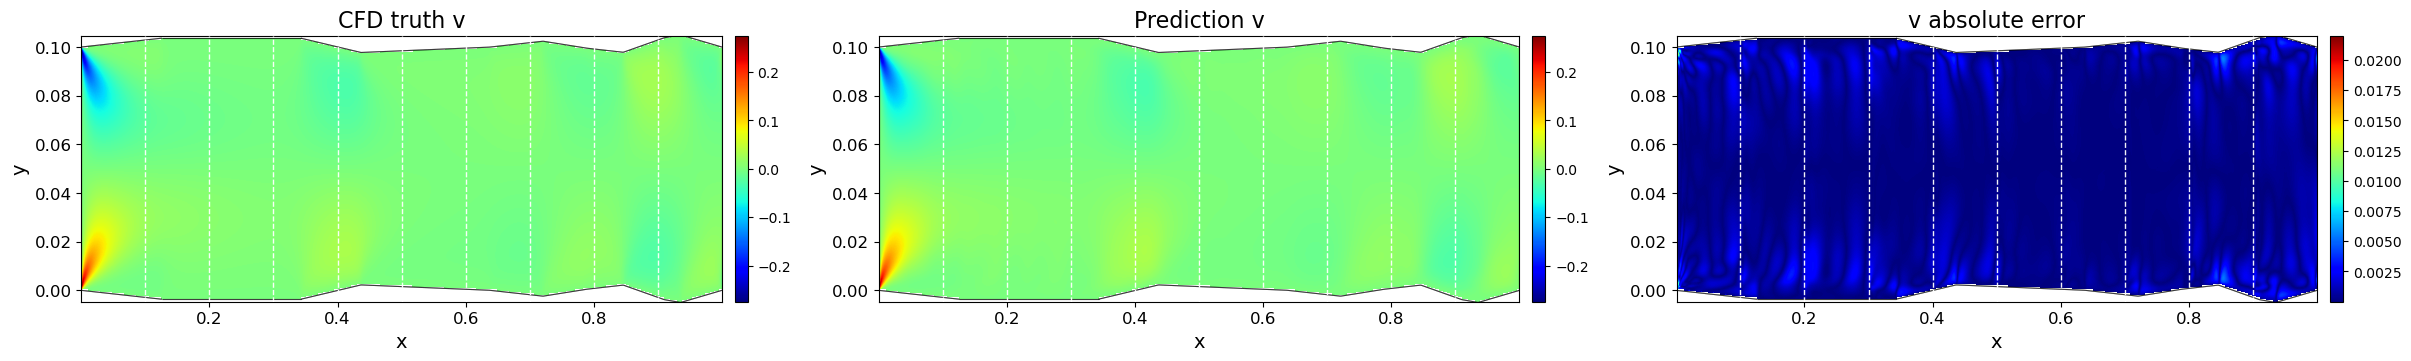

In [50]:
# Optional: inspect one saved sweep run (change run_name to compare combinations).
sweep_inspect_run_name = _sweep_weight_run_name(0.1, 0.3, 10)
sweep_inspect_dir = SWEEP_OUTPUT_ROOT / sweep_inspect_run_name

with open(sweep_inspect_dir / "metrics.json", encoding="utf-8") as f:
    sweep_inspect_metrics = json.load(f)

sweep_field_data = np.load(sweep_inspect_dir / "field_predictions.npz", allow_pickle=True)
sweep_iface_data = np.load(sweep_inspect_dir / "interface_conditions.npz")

print("Inspecting:", sweep_inspect_run_name)
print("overall_avg_rel_l2:", sweep_inspect_metrics.get("overall_avg_rel_l2"))
print("rel_l2:", sweep_inspect_metrics["rel_l2"])
print("max_field_error:", sweep_inspect_metrics["max_field_error"])
print("final_physics_losses:", sweep_inspect_metrics["final_physics_losses"])

for field_name in sweep_output_channel_names:
    field_idx = sweep_output_channel_names.index(field_name)
    plot_prediction_imshow_from_points(
        x=sweep_field_data["x"],
        y=sweep_field_data["y"],
        pred=sweep_field_data["pred"],
        truth=sweep_field_data["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_y_plot=200,
        metadata=test_data["metadata"],
        mesh_h5=case_files[TEST_CH[0]]["mesh"],
    )

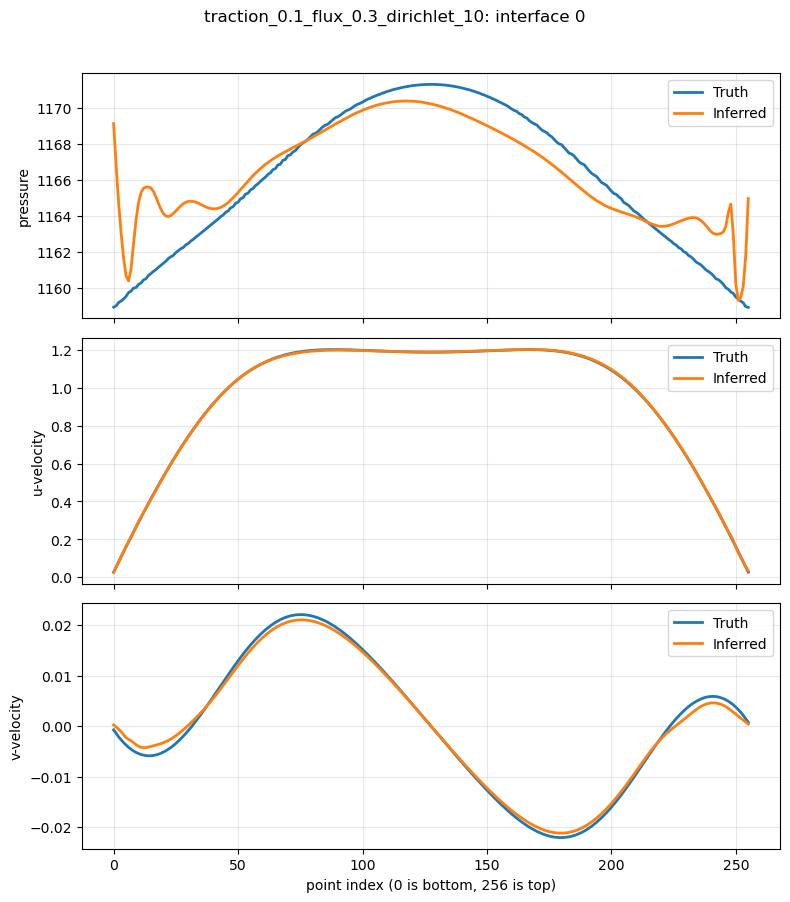

In [51]:
# Optional: interface profile plot for the same inspected sweep run.
sweep_int_eval = 0
sweep_true_if = sweep_iface_data["true_interfaces"]
sweep_infer_if = sweep_iface_data["infer_interfaces"]

fig, axes = plt.subplots(3, 1, figsize=(8, 2.2 * 4), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(sweep_true_if[sweep_int_eval, :, ch], lw=2, label="Truth")
    ax.plot(sweep_infer_if[sweep_int_eval, :, ch], lw=2, label="Inferred")
    ax.set_ylabel(sweep_channel_labels[ch])
    ax.legend(loc=1)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("point index (0 is bottom, 256 is top)")
fig.suptitle(f"{sweep_inspect_run_name}: interface {sweep_int_eval}", y=1.02)
fig.tight_layout()
plt.show()